Using device: cuda

GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS

Models to be analyzed:
  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%
  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%
  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%
  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%
  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%

GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS

Processing image 1/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png
  Generating Grad-CAM for ViT (FedProx)...
    ✗ Error: axis 2 is out of bounds for array of dimension 2
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_densenet201_gradcam.png
      Prediction: Class_2 (26.96%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_efficientnetb4_gradcam.png
      Prediction: Class_2 (25.80%)
  Generating Grad-CAM for CNN-LSTM (FedAv

AxisError: axis 2 is out of bounds for array of dimension 2

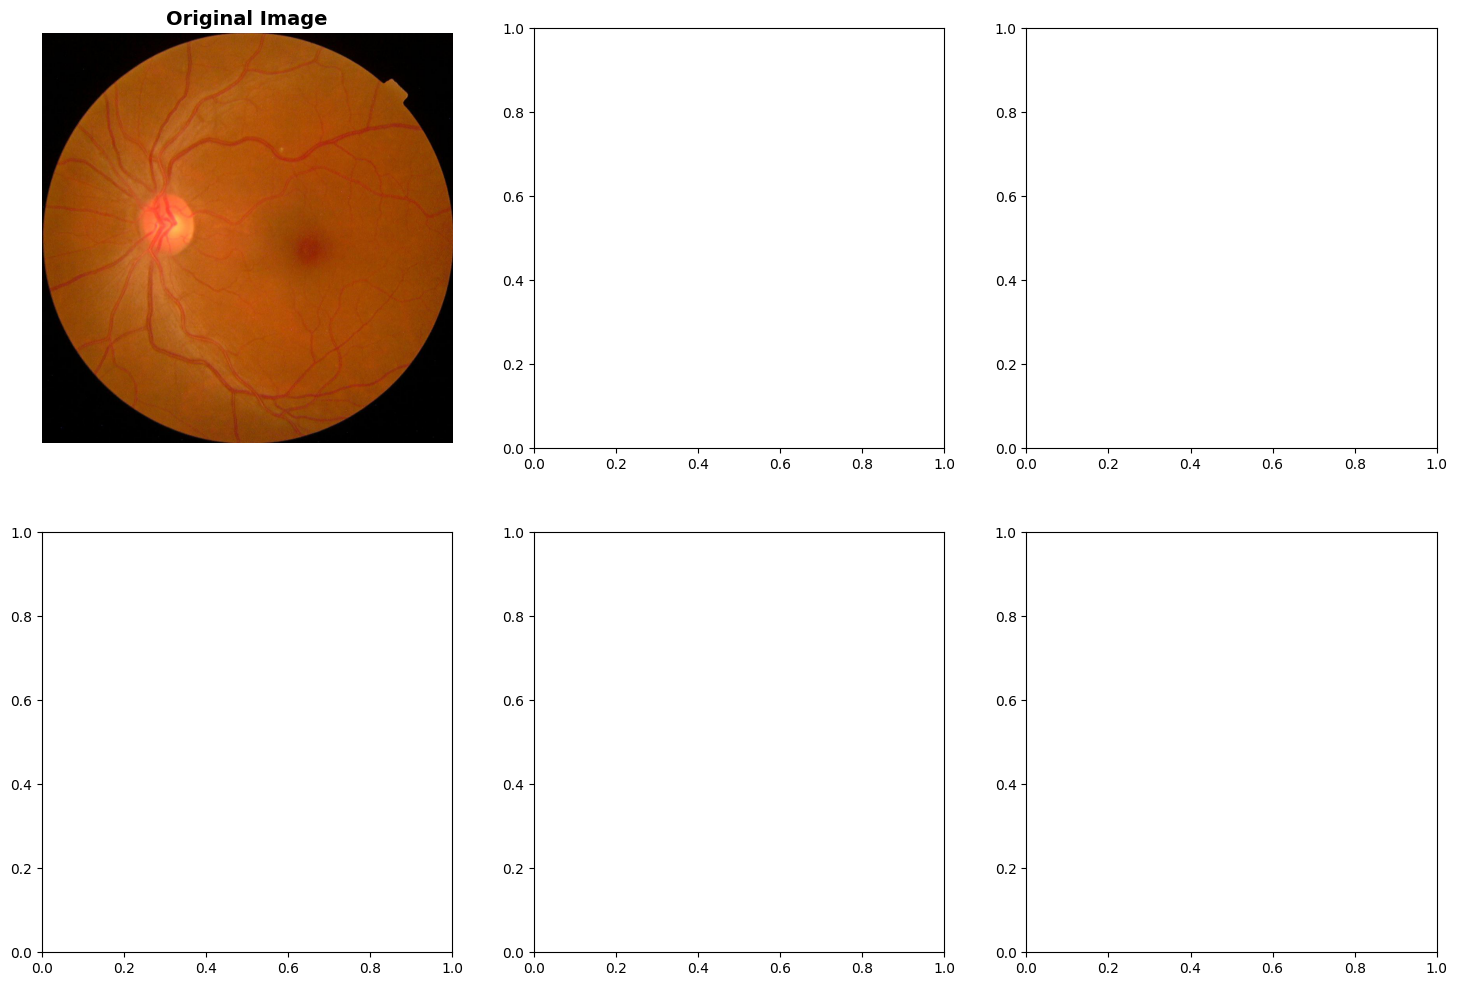

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==== Grad-CAM Implementation ====
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)

        # Handle tuple output (for MOE models)
        if isinstance(output, tuple):
            output = output[0]

        # Get target class
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        # Generate CAM
        gradients = self.gradients[0].cpu().numpy()
        activations = self.activations[0].cpu().numpy()

        # Global average pooling of gradients
        weights = np.mean(gradients, axis=(1, 2))

        # Weighted combination of activation maps
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        # ReLU and normalize
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam, target_class.item()


# ==== Model Definitions ====

# 1. Vision Transformer (ViT)
class ViTModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ViTModel, self).__init__()
        if pretrained:
            self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        else:
            self.vit = models.vit_b_16(weights=None)

        # Replace classifier
        self.vit.heads.head = nn.Sequential(
            nn.Linear(self.vit.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.vit(x)


# 2. DenseNet-201 with MOE
class DenseNet201MOE(nn.Module):
    def __init__(self, num_classes=4, num_experts=4, pretrained=True):
        super(DenseNet201MOE, self).__init__()
        if pretrained:
            self.densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        else:
            self.densenet = models.densenet201(weights=None)

        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        self.moe_classifier = MixtureOfExperts(num_features, 1024, num_classes, num_experts)
        self.is_moe = True

    def forward(self, x):
        x = self.densenet.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.moe_classifier(x)


# 3. EfficientNet-B4
class EfficientNetB4Model(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(EfficientNetB4Model, self).__init__()
        if pretrained:
            self.efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        else:
            self.efficientnet = models.efficientnet_b4(weights=None)

        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.efficientnet(x)


# 4. CNN-LSTM
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNLSTM, self).__init__()

        # CNN backbone
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        # LSTM
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=2, batch_first=True, dropout=0.3)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        # CNN features
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Reshape for LSTM: (batch, channels, h, w) -> (batch, h*w, channels)
        batch_size = x.size(0)
        x = x.view(batch_size, 512, -1).permute(0, 2, 1)

        # LSTM
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]  # Take last time step

        # Classification
        x = self.classifier(x)
        return x


# 5. RSGNet
class GatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(GatedConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gate_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.gate_bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu(self.bn(self.conv(x)))
        gate = self.sigmoid(self.gate_bn(self.gate_conv(x)))
        return out * gate


class ResidualSkipBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualSkipBlock, self).__init__()
        self.gated_conv1 = GatedConvBlock(in_channels, out_channels, stride=stride)
        self.gated_conv2 = GatedConvBlock(out_channels, out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

        self.skip_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        out = self.gated_conv1(x)
        out = self.gated_conv2(out)
        attention = self.skip_attention(out)
        out = out * attention
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class RSGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(RSGNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, 3, stride=1)
        self.layer2 = self._make_layer(64, 128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 6, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.is_moe = False

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualSkipBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualSkipBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).flatten(1)
        x = self.classifier(x)
        return x


# MOE Components
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super(GatingNetwork, self).__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim // 2, num_experts),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.gate(x)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4, top_k=2):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([ExpertNetwork(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(input_dim, num_experts)

    def forward(self, x):
        gate_weights = self.gate(x)
        top_k_weights, top_k_indices = torch.topk(gate_weights, self.top_k, dim=-1)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)

        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        batch_size, output_dim = x.size(0), expert_outputs.size(-1)
        final_output = torch.zeros(batch_size, output_dim, device=x.device)

        for i in range(self.top_k):
            expert_idx = top_k_indices[:, i]
            expert_weight = top_k_weights[:, i].unsqueeze(-1)
            selected_outputs = expert_outputs[torch.arange(batch_size), expert_idx]
            final_output += expert_weight * selected_outputs

        return final_output, gate_weights


# ==== Utility Functions ====
def get_target_layer(model, model_name):
    """Get the target layer for Grad-CAM based on model architecture"""
    if model_name == 'vit':
        # For ViT, use the last encoder block
        return model.vit.encoder.layers[-1].mlp
    elif model_name == 'densenet201':
        # For DenseNet, use the last dense block
        return model.densenet.features.denseblock4
    elif model_name == 'efficientnetb4':
        # For EfficientNet, use the last conv layer
        return model.efficientnet.features[-1]
    elif model_name == 'cnnlstm':
        # For CNN-LSTM, use the last conv layer
        return model.conv4
    elif model_name == 'rsgnet':
        # For RSGNet, use the last layer
        return model.layer4
    else:
        raise ValueError(f"Unknown model: {model_name}")


def load_and_preprocess_image(image_path, input_size):
    """Load and preprocess image"""
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0)
    return img_tensor, img


def apply_colormap_on_image(org_im, activation, alpha=0.5):
    """Apply heatmap on image"""
    # Resize activation to match image size
    heatmap = cv2.resize(activation, (org_im.size[0], org_im.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Convert PIL to numpy
    org_im_np = np.array(org_im)

    # Superimpose heatmap on original image
    superimposed_img = heatmap * alpha + org_im_np * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    return superimposed_img, heatmap


def visualize_gradcam(image_path, model, model_name, input_size, save_path, class_names):
    """Generate and visualize Grad-CAM"""
    # Load image
    img_tensor, original_img = load_and_preprocess_image(image_path, input_size)
    img_tensor = img_tensor.to(device)

    # Get target layer
    target_layer = get_target_layer(model, model_name)

    # Generate Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam, pred_class = gradcam.generate_cam(img_tensor)

    # Get prediction probabilities
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, tuple):
            output = output[0]
        probs = F.softmax(output, dim=1)[0]
        confidence = probs[pred_class].item()

    # Apply colormap
    superimposed_img, heatmap = apply_colormap_on_image(original_img, cam, alpha=0.5)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Superimposed
    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2%}',
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    return pred_class, confidence


# ==== Main Grad-CAM Generation ====
def generate_all_gradcams(image_paths, output_dir='gradcam_outputs'):
    """Generate Grad-CAM for all models"""

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3']

    # Model configurations
    models_config = {
        'vit': {
            'model': ViTModel(num_classes=4, pretrained=True),
            'input_size': 224,
            'name': 'ViT (FedProx)',
            'metrics': 'Acc: 79.5% | F1: 78.9% | AUC: 93.8% | Time: 150.5s'
        },
        'densenet201': {
            'model': DenseNet201MOE(num_classes=4, num_experts=4, pretrained=True),
            'input_size': 224,
            'name': 'DenseNet-201 (MoE-FL)',
            'metrics': 'Acc: 74.0% | F1: 65.2% | AUC: 79.5% | Time: 31.4s | Entropy: 1.37'
        },
        'efficientnetb4': {
            'model': EfficientNetB4Model(num_classes=4, pretrained=True),
            'input_size': 380,
            'name': 'EfficientNet-B4 (DP-FL)',
            'metrics': 'Acc: 72.4% | F1: 64.4% | AUC: 78.4% | Time: 42.1s'
        },
        'cnnlstm': {
            'model': CNNLSTM(num_classes=4),
            'input_size': 224,
            'name': 'CNN-LSTM (FedAvg)',
            'metrics': 'Acc: 73.2% | F1: 64.8% | AUC: 75.5% | Time: 28.9s'
        },
        'rsgnet': {
            'model': RSGNet(num_classes=4),
            'input_size': 224,
            'name': 'RSGNet (FedAvg)',
            'metrics': 'Acc: 27.3% | F1: 12.2% | AUC: 71.5% | Time: 31.7s'
        }
    }

    print("="*80)
    print("GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS")
    print("="*80)

    # Process each image
    for img_idx, image_path in enumerate(image_paths):
        print(f"\nProcessing image {img_idx + 1}/{len(image_paths)}: {image_path}")

        if not os.path.exists(image_path):
            print(f"  ⚠ Warning: Image not found: {image_path}")
            continue

        img_name = Path(image_path).stem

        # Generate Grad-CAM for each model
        for model_key, config in models_config.items():
            print(f"  Generating Grad-CAM for {config['name']}...")

            model = config['model'].to(device)
            model.eval()

            save_path = os.path.join(output_dir, f"{img_name}_{model_key}_gradcam.png")

            try:
                pred_class, confidence = visualize_gradcam(
                    image_path,
                    model,
                    model_key,
                    config['input_size'],
                    save_path,
                    class_names
                )
                print(f"    ✓ Saved: {save_path}")
                print(f"      Prediction: {class_names[pred_class]} ({confidence:.2%})")
            except Exception as e:
                print(f"    ✗ Error: {str(e)}")

            # Clean up
            del model
            torch.cuda.empty_cache()

    # Generate comparison figure
    print("\n" + "="*80)
    print("GENERATING COMPARISON FIGURE")
    print("="*80)
    generate_comparison_figure(image_paths[0], models_config, class_names, output_dir)

    print("\n" + "="*80)
    print("GRAD-CAM GENERATION COMPLETED!")
    print("="*80)
    print(f"\nAll outputs saved to: {output_dir}/")


def generate_comparison_figure(image_path, models_config, class_names, output_dir):
    """Generate a single comparison figure with all models"""

    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    # Original image
    original_img = Image.open(image_path).convert('RGB')
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Generate Grad-CAM for each model
    for idx, (model_key, config) in enumerate(models_config.items(), start=1):
        print(f"  Processing {config['name']}...")

        model = config['model'].to(device)
        model.eval()

        img_tensor, orig_img = load_and_preprocess_image(image_path, config['input_size'])
        img_tensor = img_tensor.to(device)

        target_layer = get_target_layer(model, model_key)
        gradcam = GradCAM(model, target_layer)
        cam, pred_class = gradcam.generate_cam(img_tensor)

        with torch.no_grad():
            output = model(img_tensor)
            if isinstance(output, tuple):
                output = output[0]
            probs = F.softmax(output, dim=1)[0]
            confidence = probs[pred_class].item()

        superimposed_img, _ = apply_colormap_on_image(orig_img, cam, alpha=0.5)

        axes[idx].imshow(superimposed_img)
        title = f"{config['name']}\n{config['metrics']}\nPred: {class_names[pred_class]} ({confidence:.1%})"
        axes[idx].set_title(title, fontsize=10, fontweight='bold')
        axes[idx].axis('off')

        del model
        torch.cuda.empty_cache()

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'all_models_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Comparison figure saved: {save_path}")


# ==== Run Grad-CAM Generation ====
if __name__ == "__main__":
    # Example usage - provide paths to your test images
    image_paths = [
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e79e10907295.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e8ddfc9709ce.png",
    ]

    # Or load all images from a folder
    # test_folder = "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images"
    # image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    output_directory = 'gradcam_outputs'

    print("\n" + "="*80)
    print("GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS")
    print("="*80)
    print("\nModels to be analyzed:")
    print("  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%")
    print("  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%")
    print("  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%")
    print("  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%")
    print("  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%")
    print("\n" + "="*80)

    generate_all_gradcams(image_paths, output_directory)

    print("\nGrad-CAM outputs include:")
    print("  • Individual Grad-CAM for each model and image")
    print("  • Comparison figure with all models side-by-side")
    print("  • Prediction labels with confidence scores")
    print("  • Model performance metrics displayed")

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==== Grad-CAM Implementation ====
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)

        # Handle tuple output (for MOE models)
        if isinstance(output, tuple):
            output = output[0]

        # Get target class
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        # Generate CAM
        gradients = self.gradients[0].cpu().numpy()
        activations = self.activations[0].cpu().numpy()

        # Check if activations have spatial dimensions
        if len(activations.shape) == 3:
            # Standard CNN case: (channels, height, width)
            weights = np.mean(gradients, axis=(1, 2))
            cam = np.zeros(activations.shape[1:], dtype=np.float32)
            for i, w in enumerate(weights):
                cam += w * activations[i]
        elif len(activations.shape) == 2:
            # ViT case: (sequence_length, hidden_dim)
            # Use attention weights as approximation
            weights = np.abs(gradients).mean(axis=1)
            # Reshape to approximate spatial layout
            seq_len = activations.shape[0]
            grid_size = int(np.sqrt(seq_len - 1))  # -1 for class token
            weights = weights[1:]  # Remove class token
            cam = weights[:grid_size*grid_size].reshape(grid_size, grid_size)
        else:
            raise ValueError(f"Unexpected activation shape: {activations.shape}")

        # ReLU and normalize
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam, target_class.item()


# ==== Model Definitions ====

# 1. Vision Transformer (ViT)
class ViTModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ViTModel, self).__init__()
        if pretrained:
            self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        else:
            self.vit = models.vit_b_16(weights=None)

        # Replace classifier
        self.vit.heads.head = nn.Sequential(
            nn.Linear(self.vit.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.vit(x)


# 2. DenseNet-201 with MOE
class DenseNet201MOE(nn.Module):
    def __init__(self, num_classes=4, num_experts=4, pretrained=True):
        super(DenseNet201MOE, self).__init__()
        if pretrained:
            self.densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        else:
            self.densenet = models.densenet201(weights=None)

        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        self.moe_classifier = MixtureOfExperts(num_features, 1024, num_classes, num_experts)
        self.is_moe = True

    def forward(self, x):
        x = self.densenet.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.moe_classifier(x)


# 3. EfficientNet-B4
class EfficientNetB4Model(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(EfficientNetB4Model, self).__init__()
        if pretrained:
            self.efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        else:
            self.efficientnet = models.efficientnet_b4(weights=None)

        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.efficientnet(x)


# 4. CNN-LSTM
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNLSTM, self).__init__()

        # CNN backbone
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        # LSTM
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=2, batch_first=True, dropout=0.3)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        # CNN features
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Reshape for LSTM: (batch, channels, h, w) -> (batch, h*w, channels)
        batch_size = x.size(0)
        x = x.view(batch_size, 512, -1).permute(0, 2, 1)

        # LSTM - set to train mode for gradients
        if self.training:
            lstm_out, _ = self.lstm(x)
        else:
            # For evaluation with gradients (Grad-CAM), temporarily enable train mode
            self.lstm.train()
            lstm_out, _ = self.lstm(x)
            self.lstm.eval()

        x = lstm_out[:, -1, :]  # Take last time step

        # Classification
        x = self.classifier(x)
        return x


# 5. RSGNet
class GatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(GatedConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gate_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.gate_bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu(self.bn(self.conv(x)))
        gate = self.sigmoid(self.gate_bn(self.gate_conv(x)))
        return out * gate


class ResidualSkipBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualSkipBlock, self).__init__()
        self.gated_conv1 = GatedConvBlock(in_channels, out_channels, stride=stride)
        self.gated_conv2 = GatedConvBlock(out_channels, out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

        self.skip_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        out = self.gated_conv1(x)
        out = self.gated_conv2(out)
        attention = self.skip_attention(out)
        out = out * attention
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class RSGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(RSGNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, 3, stride=1)
        self.layer2 = self._make_layer(64, 128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 6, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.is_moe = False

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualSkipBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualSkipBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).flatten(1)
        x = self.classifier(x)
        return x


# MOE Components
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super(GatingNetwork, self).__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim // 2, num_experts),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.gate(x)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4, top_k=2):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([ExpertNetwork(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(input_dim, num_experts)

    def forward(self, x):
        gate_weights = self.gate(x)
        top_k_weights, top_k_indices = torch.topk(gate_weights, self.top_k, dim=-1)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)

        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        batch_size, output_dim = x.size(0), expert_outputs.size(-1)
        final_output = torch.zeros(batch_size, output_dim, device=x.device)

        for i in range(self.top_k):
            expert_idx = top_k_indices[:, i]
            expert_weight = top_k_weights[:, i].unsqueeze(-1)
            selected_outputs = expert_outputs[torch.arange(batch_size), expert_idx]
            final_output += expert_weight * selected_outputs

        return final_output, gate_weights


# ==== Utility Functions ====
def get_target_layer(model, model_name):
    """Get the target layer for Grad-CAM based on model architecture"""
    if model_name == 'vit':
        # For ViT, use the last layer norm before classification
        return model.vit.encoder.ln
    elif model_name == 'densenet201':
        # For DenseNet, use the last dense block
        return model.densenet.features.denseblock4
    elif model_name == 'efficientnetb4':
        # For EfficientNet, use the last conv layer
        return model.efficientnet.features[-1]
    elif model_name == 'cnnlstm':
        # For CNN-LSTM, use the last conv layer
        return model.conv4
    elif model_name == 'rsgnet':
        # For RSGNet, use the last layer
        return model.layer4
    else:
        raise ValueError(f"Unknown model: {model_name}")


def load_and_preprocess_image(image_path, input_size):
    """Load and preprocess image"""
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0)
    return img_tensor, img


def apply_colormap_on_image(org_im, activation, alpha=0.5):
    """Apply heatmap on image"""
    # Resize activation to match image size
    heatmap = cv2.resize(activation, (org_im.size[0], org_im.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Convert PIL to numpy
    org_im_np = np.array(org_im)

    # Superimpose heatmap on original image
    superimposed_img = heatmap * alpha + org_im_np * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    return superimposed_img, heatmap


def visualize_gradcam(image_path, model, model_name, input_size, save_path, class_names):
    """Generate and visualize Grad-CAM"""
    # Load image
    img_tensor, original_img = load_and_preprocess_image(image_path, input_size)
    img_tensor = img_tensor.to(device)

    # Get target layer
    target_layer = get_target_layer(model, model_name)

    # Generate Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam, pred_class = gradcam.generate_cam(img_tensor)

    # Get prediction probabilities
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, tuple):
            output = output[0]
        probs = F.softmax(output, dim=1)[0]
        confidence = probs[pred_class].item()

    # Apply colormap
    superimposed_img, heatmap = apply_colormap_on_image(original_img, cam, alpha=0.5)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Superimposed
    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2%}',
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    return pred_class, confidence


# ==== Main Grad-CAM Generation ====
def generate_all_gradcams(image_paths, output_dir='gradcam_outputs'):
    """Generate Grad-CAM for all models"""

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3']

    # Model configurations
    models_config = {
        'vit': {
            'model': ViTModel(num_classes=4, pretrained=True),
            'input_size': 224,
            'name': 'ViT (FedProx)',
            'metrics': 'Acc: 79.5% | F1: 78.9% | AUC: 93.8% | Time: 150.5s'
        },
        'densenet201': {
            'model': DenseNet201MOE(num_classes=4, num_experts=4, pretrained=True),
            'input_size': 224,
            'name': 'DenseNet-201 (MoE-FL)',
            'metrics': 'Acc: 74.0% | F1: 65.2% | AUC: 79.5% | Time: 31.4s | Entropy: 1.37'
        },
        'efficientnetb4': {
            'model': EfficientNetB4Model(num_classes=4, pretrained=True),
            'input_size': 380,
            'name': 'EfficientNet-B4 (DP-FL)',
            'metrics': 'Acc: 72.4% | F1: 64.4% | AUC: 78.4% | Time: 42.1s'
        },
        'cnnlstm': {
            'model': CNNLSTM(num_classes=4),
            'input_size': 224,
            'name': 'CNN-LSTM (FedAvg)',
            'metrics': 'Acc: 73.2% | F1: 64.8% | AUC: 75.5% | Time: 28.9s'
        },
        'rsgnet': {
            'model': RSGNet(num_classes=4),
            'input_size': 224,
            'name': 'RSGNet (FedAvg)',
            'metrics': 'Acc: 27.3% | F1: 12.2% | AUC: 71.5% | Time: 31.7s'
        }
    }

    print("="*80)
    print("GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS")
    print("="*80)

    # Process each image
    for img_idx, image_path in enumerate(image_paths):
        print(f"\nProcessing image {img_idx + 1}/{len(image_paths)}: {image_path}")

        if not os.path.exists(image_path):
            print(f"  ⚠ Warning: Image not found: {image_path}")
            continue

        img_name = Path(image_path).stem

        # Generate Grad-CAM for each model
        for model_key, config in models_config.items():
            print(f"  Generating Grad-CAM for {config['name']}...")

            model = config['model'].to(device)
            model.eval()

            save_path = os.path.join(output_dir, f"{img_name}_{model_key}_gradcam.png")

            try:
                pred_class, confidence = visualize_gradcam(
                    image_path,
                    model,
                    model_key,
                    config['input_size'],
                    save_path,
                    class_names
                )
                print(f"    ✓ Saved: {save_path}")
                print(f"      Prediction: {class_names[pred_class]} ({confidence:.2%})")
            except Exception as e:
                print(f"    ✗ Error: {str(e)}")

            # Clean up
            del model
            torch.cuda.empty_cache()

    # Generate comparison figure
    print("\n" + "="*80)
    print("GENERATING COMPARISON FIGURE")
    print("="*80)
    generate_comparison_figure(image_paths[0], models_config, class_names, output_dir)

    print("\n" + "="*80)
    print("GRAD-CAM GENERATION COMPLETED!")
    print("="*80)
    print(f"\nAll outputs saved to: {output_dir}/")


def generate_comparison_figure(image_path, models_config, class_names, output_dir):
    """Generate a single comparison figure with all models"""

    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    # Original image
    original_img = Image.open(image_path).convert('RGB')
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Generate Grad-CAM for each model
    for idx, (model_key, config) in enumerate(models_config.items(), start=1):
        print(f"  Processing {config['name']}...")

        model = config['model'].to(device)
        model.eval()

        img_tensor, orig_img = load_and_preprocess_image(image_path, config['input_size'])
        img_tensor = img_tensor.to(device)

        target_layer = get_target_layer(model, model_key)
        gradcam = GradCAM(model, target_layer)
        cam, pred_class = gradcam.generate_cam(img_tensor)

        with torch.no_grad():
            output = model(img_tensor)
            if isinstance(output, tuple):
                output = output[0]
            probs = F.softmax(output, dim=1)[0]
            confidence = probs[pred_class].item()

        superimposed_img, _ = apply_colormap_on_image(orig_img, cam, alpha=0.5)

        axes[idx].imshow(superimposed_img)
        title = f"{config['name']}\n{config['metrics']}\nPred: {class_names[pred_class]} ({confidence:.1%})"
        axes[idx].set_title(title, fontsize=10, fontweight='bold')
        axes[idx].axis('off')

        del model
        torch.cuda.empty_cache()

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'all_models_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Comparison figure saved: {save_path}")


# ==== Run Grad-CAM Generation ====
if __name__ == "__main__":
    # Example usage - provide paths to your test images
    image_paths = [
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e79e10907295.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e8ddfc9709ce.png",
    ]

    # Or load all images from a folder
    # test_folder = "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images"
    # image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    output_directory = 'gradcam_outputs'

    print("\n" + "="*80)
    print("GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS")
    print("="*80)
    print("\nModels to be analyzed:")
    print("  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%")
    print("  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%")
    print("  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%")
    print("  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%")
    print("  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%")
    print("\n" + "="*80)

    generate_all_gradcams(image_paths, output_directory)

    print("\nGrad-CAM outputs include:")
    print("  • Individual Grad-CAM for each model and image")
    print("  • Comparison figure with all models side-by-side")
    print("  • Prediction labels with confidence scores")
    print("  • Model performance metrics displayed")

Using device: cuda

GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS

Models to be analyzed:
  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%
  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%
  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%
  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%
  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%

GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS

Processing image 1/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png
  Generating Grad-CAM for ViT (FedProx)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_vit_gradcam.png
      Prediction: Class_2 (31.37%)
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_densenet201_gradcam.png
      Prediction: Class_1 (26.45%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_efficientnetb4_gradcam.png
      Prediction: Class_3 (26.11%)
  Generati

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==== Grad-CAM Implementation ====
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass
        self.model.eval()
        output = self.model(input_tensor)

        # Handle tuple output (for MOE models)
        if isinstance(output, tuple):
            output = output[0]

        # Get target class
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        # Generate CAM
        gradients = self.gradients.cpu().numpy()
        activations = self.activations.cpu().numpy()

        # Handle different activation shapes
        if len(activations.shape) == 4:
            # Standard CNN: (batch, channels, height, width)
            gradients = gradients[0]
            activations = activations[0]
            weights = np.mean(gradients, axis=(1, 2))
            cam = np.zeros(activations.shape[1:], dtype=np.float32)
            for i, w in enumerate(weights):
                cam += w * activations[i]

        elif len(activations.shape) == 3:
            # ViT: (batch, seq_len, hidden_dim)
            gradients = gradients[0]  # (seq_len, hidden_dim)
            activations = activations[0]  # (seq_len, hidden_dim)

            # Use attention-based approach
            weights = np.abs(gradients).mean(axis=1)  # (seq_len,)

            # Remove class token if present
            if weights.shape[0] == 197:  # 14x14 + 1 class token for 224x224 input
                weights = weights[1:]
                grid_size = 14
            else:
                grid_size = int(np.sqrt(weights.shape[0]))
                weights = weights[:grid_size*grid_size]

            cam = weights.reshape(grid_size, grid_size)
        else:
            raise ValueError(f"Unexpected activation shape: {activations.shape}")

        # ReLU and normalize
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam, target_class.item()


# ==== Model Definitions ====

# 1. Vision Transformer (ViT)
class ViTModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ViTModel, self).__init__()
        if pretrained:
            self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        else:
            self.vit = models.vit_b_16(weights=None)

        # Replace classifier
        self.vit.heads.head = nn.Sequential(
            nn.Linear(self.vit.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.vit(x)


# 2. DenseNet-201 with MOE
class DenseNet201MOE(nn.Module):
    def __init__(self, num_classes=4, num_experts=4, pretrained=True):
        super(DenseNet201MOE, self).__init__()
        if pretrained:
            self.densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        else:
            self.densenet = models.densenet201(weights=None)

        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        self.moe_classifier = MixtureOfExperts(num_features, 1024, num_classes, num_experts)
        self.is_moe = True

    def forward(self, x):
        x = self.densenet.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.moe_classifier(x)


# 3. EfficientNet-B4
class EfficientNetB4Model(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(EfficientNetB4Model, self).__init__()
        if pretrained:
            self.efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        else:
            self.efficientnet = models.efficientnet_b4(weights=None)

        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.efficientnet(x)


# 4. CNN-LSTM
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNLSTM, self).__init__()

        # CNN backbone
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        # LSTM
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=2, batch_first=True, dropout=0.3)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        # CNN features
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Reshape for LSTM: (batch, channels, h, w) -> (batch, h*w, channels)
        batch_size = x.size(0)
        x = x.view(batch_size, 512, -1).permute(0, 2, 1)

        # LSTM - enable dropout for gradient flow
        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]  # Take last time step

        # Classification
        x = self.classifier(x)
        return x


# 5. RSGNet
class GatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(GatedConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gate_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.gate_bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu(self.bn(self.conv(x)))
        gate = self.sigmoid(self.gate_bn(self.gate_conv(x)))
        return out * gate


class ResidualSkipBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualSkipBlock, self).__init__()
        self.gated_conv1 = GatedConvBlock(in_channels, out_channels, stride=stride)
        self.gated_conv2 = GatedConvBlock(out_channels, out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

        self.skip_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        out = self.gated_conv1(x)
        out = self.gated_conv2(out)
        attention = self.skip_attention(out)
        out = out * attention
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class RSGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(RSGNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, 3, stride=1)
        self.layer2 = self._make_layer(64, 128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 6, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.is_moe = False

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualSkipBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualSkipBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).flatten(1)
        x = self.classifier(x)
        return x


# MOE Components
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super(GatingNetwork, self).__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim // 2, num_experts),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.gate(x)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4, top_k=2):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([ExpertNetwork(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(input_dim, num_experts)

    def forward(self, x):
        gate_weights = self.gate(x)
        top_k_weights, top_k_indices = torch.topk(gate_weights, self.top_k, dim=-1)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)

        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        batch_size, output_dim = x.size(0), expert_outputs.size(-1)
        final_output = torch.zeros(batch_size, output_dim, device=x.device)

        for i in range(self.top_k):
            expert_idx = top_k_indices[:, i]
            expert_weight = top_k_weights[:, i].unsqueeze(-1)
            selected_outputs = expert_outputs[torch.arange(batch_size), expert_idx]
            final_output += expert_weight * selected_outputs

        return final_output, gate_weights


# ==== Utility Functions ====
def get_target_layer(model, model_name):
    """Get the target layer for Grad-CAM based on model architecture"""
    if model_name == 'vit':
        # For ViT, use the last encoder layer norm
        return model.vit.encoder.ln
    elif model_name == 'densenet201':
        # For DenseNet, use the last dense block
        return model.densenet.features.denseblock4
    elif model_name == 'efficientnetb4':
        # For EfficientNet, use the last conv layer
        return model.efficientnet.features[-1]
    elif model_name == 'cnnlstm':
        # For CNN-LSTM, use the last conv layer
        return model.conv4
    elif model_name == 'rsgnet':
        # For RSGNet, use the last layer
        return model.layer4
    else:
        raise ValueError(f"Unknown model: {model_name}")


def load_and_preprocess_image(image_path, input_size):
    """Load and preprocess image"""
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0)
    return img_tensor, img


def apply_colormap_on_image(org_im, activation, alpha=0.5):
    """Apply heatmap on image"""
    # Resize activation to match image size
    heatmap = cv2.resize(activation, (org_im.size[0], org_im.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Convert PIL to numpy
    org_im_np = np.array(org_im)

    # Superimpose heatmap on original image
    superimposed_img = heatmap * alpha + org_im_np * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    return superimposed_img, heatmap


def visualize_gradcam(image_path, model, model_name, input_size, save_path, class_names):
    """Generate and visualize Grad-CAM"""
    # Load image
    img_tensor, original_img = load_and_preprocess_image(image_path, input_size)
    img_tensor = img_tensor.to(device)

    # Get target layer
    target_layer = get_target_layer(model, model_name)

    # Generate Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam, pred_class = gradcam.generate_cam(img_tensor)

    # Get prediction probabilities
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, tuple):
            output = output[0]
        probs = F.softmax(output, dim=1)[0]
        confidence = probs[pred_class].item()

    # Apply colormap
    superimposed_img, heatmap = apply_colormap_on_image(original_img, cam, alpha=0.5)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Superimposed
    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2%}',
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    return pred_class, confidence


# ==== Main Grad-CAM Generation ====
def generate_all_gradcams(image_paths, output_dir='gradcam_outputs'):
    """Generate Grad-CAM for all models"""

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3']

    # Model configurations
    models_config = {
        'vit': {
            'model': ViTModel(num_classes=4, pretrained=True),
            'input_size': 224,
            'name': 'ViT (FedProx)',
            'metrics': 'Acc: 79.5% | F1: 78.9% | AUC: 93.8% | Time: 150.5s'
        },
        'densenet201': {
            'model': DenseNet201MOE(num_classes=4, num_experts=4, pretrained=True),
            'input_size': 224,
            'name': 'DenseNet-201 (MoE-FL)',
            'metrics': 'Acc: 74.0% | F1: 65.2% | AUC: 79.5% | Time: 31.4s | Entropy: 1.37'
        },
        'efficientnetb4': {
            'model': EfficientNetB4Model(num_classes=4, pretrained=True),
            'input_size': 380,
            'name': 'EfficientNet-B4 (DP-FL)',
            'metrics': 'Acc: 72.4% | F1: 64.4% | AUC: 78.4% | Time: 42.1s'
        },
        'cnnlstm': {
            'model': CNNLSTM(num_classes=4),
            'input_size': 224,
            'name': 'CNN-LSTM (FedAvg)',
            'metrics': 'Acc: 73.2% | F1: 64.8% | AUC: 75.5% | Time: 28.9s'
        },
        'rsgnet': {
            'model': RSGNet(num_classes=4),
            'input_size': 224,
            'name': 'RSGNet (FedAvg)',
            'metrics': 'Acc: 27.3% | F1: 12.2% | AUC: 71.5% | Time: 31.7s'
        }
    }

    print("="*80)
    print("GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS")
    print("="*80)

    # Process each image
    for img_idx, image_path in enumerate(image_paths):
        print(f"\nProcessing image {img_idx + 1}/{len(image_paths)}: {image_path}")

        if not os.path.exists(image_path):
            print(f"  ⚠ Warning: Image not found: {image_path}")
            continue

        img_name = Path(image_path).stem

        # Generate Grad-CAM for each model
        for model_key, config in models_config.items():
            print(f"  Generating Grad-CAM for {config['name']}...")

            model = config['model'].to(device)
            model.eval()

            save_path = os.path.join(output_dir, f"{img_name}_{model_key}_gradcam.png")

            try:
                pred_class, confidence = visualize_gradcam(
                    image_path,
                    model,
                    model_key,
                    config['input_size'],
                    save_path,
                    class_names
                )
                print(f"    ✓ Saved: {save_path}")
                print(f"      Prediction: {class_names[pred_class]} ({confidence:.2%})")
            except Exception as e:
                print(f"    ✗ Error: {str(e)}")
                import traceback
                traceback.print_exc()

            # Clean up
            del model
            torch.cuda.empty_cache()

    # Generate comparison figure
    print("\n" + "="*80)
    print("GENERATING COMPARISON FIGURE")
    print("="*80)
    generate_comparison_figure(image_paths[0], models_config, class_names, output_dir)

    print("\n" + "="*80)
    print("GRAD-CAM GENERATION COMPLETED!")
    print("="*80)
    print(f"\nAll outputs saved to: {output_dir}/")


def generate_comparison_figure(image_path, models_config, class_names, output_dir):
    """Generate a single comparison figure with all models"""

    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    # Original image
    original_img = Image.open(image_path).convert('RGB')
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Generate Grad-CAM for each model
    for idx, (model_key, config) in enumerate(models_config.items(), start=1):
        print(f"  Processing {config['name']}...")

        try:
            model = config['model'].to(device)
            model.eval()

            img_tensor, orig_img = load_and_preprocess_image(image_path, config['input_size'])
            img_tensor = img_tensor.to(device)

            target_layer = get_target_layer(model, model_key)
            gradcam = GradCAM(model, target_layer)
            cam, pred_class = gradcam.generate_cam(img_tensor)

            with torch.no_grad():
                output = model(img_tensor)
                if isinstance(output, tuple):
                    output = output[0]
                probs = F.softmax(output, dim=1)[0]
                confidence = probs[pred_class].item()

            superimposed_img, _ = apply_colormap_on_image(orig_img, cam, alpha=0.5)

            axes[idx].imshow(superimposed_img)
            title = f"{config['name']}\n{config['metrics']}\nPred: {class_names[pred_class]} ({confidence:.1%})"
            axes[idx].set_title(title, fontsize=10, fontweight='bold')
            axes[idx].axis('off')

            del model
            torch.cuda.empty_cache()
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center')
            axes[idx].axis('off')

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'all_models_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Comparison figure saved: {save_path}")


# ==== Run Grad-CAM Generation ====
if __name__ == "__main__":
    # Example usage - provide paths to your test images
    image_paths = [
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e79e10907295.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e8ddfc9709ce.png",
    ]

    # Or load all images from a folder
    # test_folder = "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images"
    # image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    output_directory = 'gradcam_outputs'

    print("\n" + "="*80)
    print("GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS")
    print("="*80)
    print("\nModels to be analyzed:")
    print("  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%")
    print("  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%")
    print("  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%")
    print("  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%")
    print("  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%")
    print("\n" + "="*80)

    generate_all_gradcams(image_paths, output_directory)

    print("\nGrad-CAM outputs include:")
    print("  • Individual Grad-CAM for each model and image")
    print("  • Comparison figure with all models side-by-side")
    print("  • Prediction labels with confidence scores")
    print("  • Model performance metrics displayed")

Using device: cuda

GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS

Models to be analyzed:
  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%
  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%
  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%
  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%
  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%

GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS

Processing image 1/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png
  Generating Grad-CAM for ViT (FedProx)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_vit_gradcam.png
      Prediction: Class_0 (30.65%)
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_densenet201_gradcam.png
      Prediction: Class_2 (25.41%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: gradcam_outputs/e4dcca36ceb4_efficientnetb4_gradcam.png
      Prediction: Class_1 (25.89%)
  Generati

Traceback (most recent call last):
  File "/tmp/ipython-input-2844151253.py", line 556, in generate_all_gradcams
    pred_class, confidence = visualize_gradcam(
                             ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 450, in visualize_gradcam
    cam, pred_class = gradcam.generate_cam(img_tensor)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 50, in generate_cam
    class_loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 829, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

    ✓ Saved: gradcam_outputs/e4dcca36ceb4_rsgnet_gradcam.png
      Prediction: Class_0 (25.61%)

Processing image 2/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e79e10907295.png
  Generating Grad-CAM for ViT (FedProx)...
    ✓ Saved: gradcam_outputs/e79e10907295_vit_gradcam.png
      Prediction: Class_0 (36.37%)
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: gradcam_outputs/e79e10907295_densenet201_gradcam.png
      Prediction: Class_1 (25.36%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: gradcam_outputs/e79e10907295_efficientnetb4_gradcam.png
      Prediction: Class_1 (26.41%)
  Generating Grad-CAM for CNN-LSTM (FedAvg)...
    ✗ Error: cudnn RNN backward can only be called in training mode
  Generating Grad-CAM for RSGNet (FedAvg)...


Traceback (most recent call last):
  File "/tmp/ipython-input-2844151253.py", line 556, in generate_all_gradcams
    pred_class, confidence = visualize_gradcam(
                             ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 450, in visualize_gradcam
    cam, pred_class = gradcam.generate_cam(img_tensor)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 50, in generate_cam
    class_loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 829, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

    ✓ Saved: gradcam_outputs/e79e10907295_rsgnet_gradcam.png
      Prediction: Class_0 (25.62%)

Processing image 3/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e8ddfc9709ce.png
  Generating Grad-CAM for ViT (FedProx)...
    ✓ Saved: gradcam_outputs/e8ddfc9709ce_vit_gradcam.png
      Prediction: Class_0 (32.23%)
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: gradcam_outputs/e8ddfc9709ce_densenet201_gradcam.png
      Prediction: Class_3 (25.23%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: gradcam_outputs/e8ddfc9709ce_efficientnetb4_gradcam.png
      Prediction: Class_1 (26.10%)
  Generating Grad-CAM for CNN-LSTM (FedAvg)...
    ✗ Error: cudnn RNN backward can only be called in training mode
  Generating Grad-CAM for RSGNet (FedAvg)...


Traceback (most recent call last):
  File "/tmp/ipython-input-2844151253.py", line 556, in generate_all_gradcams
    pred_class, confidence = visualize_gradcam(
                             ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 450, in visualize_gradcam
    cam, pred_class = gradcam.generate_cam(img_tensor)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2844151253.py", line 50, in generate_cam
    class_loss.backward()
  File "/usr/local/lib/python3.12/dist-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py", line 829, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

    ✓ Saved: gradcam_outputs/e8ddfc9709ce_rsgnet_gradcam.png
      Prediction: Class_0 (25.61%)

GENERATING COMPARISON FIGURE
  Processing ViT (FedProx)...
  Processing DenseNet-201 (MoE-FL)...
  Processing EfficientNet-B4 (DP-FL)...
  Processing CNN-LSTM (FedAvg)...
  Processing RSGNet (FedAvg)...
✓ Comparison figure saved: gradcam_outputs/all_models_comparison.png

GRAD-CAM GENERATION COMPLETED!

All outputs saved to: gradcam_outputs/

Grad-CAM outputs include:
  • Individual Grad-CAM for each model and image
  • Comparison figure with all models side-by-side
  • Prediction labels with confidence scores
  • Model performance metrics displayed


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==== Grad-CAM Implementation ====
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass - keep model in eval mode but enable gradients
        self.model.eval()

        # Special handling for models with RNN layers (CNN-LSTM)
        requires_training_mode = False
        if hasattr(self.model, 'lstm'):
            requires_training_mode = True
            self.model.lstm.train()  # LSTM needs train mode for backward pass

        # Enable gradient computation
        with torch.set_grad_enabled(True):
            output = self.model(input_tensor)

        # Handle tuple output (for MOE models)
        if isinstance(output, tuple):
            output = output[0]

        # Get target class
        if target_class is None:
            target_class = output.argmax(dim=1)

        # Backward pass
        self.model.zero_grad()
        class_loss = output[0, target_class]
        class_loss.backward()

        # Restore model state
        if requires_training_mode:
            self.model.lstm.eval()

        # Generate CAM
        gradients = self.gradients.cpu().numpy()
        activations = self.activations.cpu().numpy()

        # Handle different activation shapes
        if len(activations.shape) == 4:
            # Standard CNN: (batch, channels, height, width)
            gradients = gradients[0]
            activations = activations[0]
            weights = np.mean(gradients, axis=(1, 2))
            cam = np.zeros(activations.shape[1:], dtype=np.float32)
            for i, w in enumerate(weights):
                cam += w * activations[i]

        elif len(activations.shape) == 3:
            # ViT: (batch, seq_len, hidden_dim)
            gradients = gradients[0]  # (seq_len, hidden_dim)
            activations = activations[0]  # (seq_len, hidden_dim)

            # Use attention-based approach
            weights = np.abs(gradients).mean(axis=1)  # (seq_len,)

            # Remove class token if present
            if weights.shape[0] == 197:  # 14x14 + 1 class token for 224x224 input
                weights = weights[1:]
                grid_size = 14
            else:
                grid_size = int(np.sqrt(weights.shape[0]))
                weights = weights[:grid_size*grid_size]

            cam = weights.reshape(grid_size, grid_size)
        else:
            raise ValueError(f"Unexpected activation shape: {activations.shape}")

        # ReLU and normalize
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam, target_class.item()


# ==== Model Definitions ====

# 1. Vision Transformer (ViT)
class ViTModel(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(ViTModel, self).__init__()
        if pretrained:
            self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        else:
            self.vit = models.vit_b_16(weights=None)

        # Replace classifier
        self.vit.heads.head = nn.Sequential(
            nn.Linear(self.vit.heads.head.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.vit(x)


# 2. DenseNet-201 with MOE
class DenseNet201MOE(nn.Module):
    def __init__(self, num_classes=4, num_experts=4, pretrained=True):
        super(DenseNet201MOE, self).__init__()
        if pretrained:
            self.densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
        else:
            self.densenet = models.densenet201(weights=None)

        num_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        self.moe_classifier = MixtureOfExperts(num_features, 1024, num_classes, num_experts)
        self.is_moe = True

    def forward(self, x):
        x = self.densenet.features(x)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.moe_classifier(x)


# 3. EfficientNet-B4
class EfficientNetB4Model(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super(EfficientNetB4Model, self).__init__()
        if pretrained:
            self.efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        else:
            self.efficientnet = models.efficientnet_b4(weights=None)

        num_features = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        return self.efficientnet(x)


# 4. CNN-LSTM
class CNNLSTM(nn.Module):
    def __init__(self, num_classes=4):
        super(CNNLSTM, self).__init__()

        # CNN backbone
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        # LSTM
        self.lstm = nn.LSTM(input_size=512, hidden_size=256, num_layers=2, batch_first=True, dropout=0.3)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        self.is_moe = False

    def forward(self, x):
        # CNN features
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Reshape for LSTM: (batch, channels, h, w) -> (batch, h*w, channels)
        batch_size = x.size(0)
        x = x.view(batch_size, 512, -1).permute(0, 2, 1)

        # LSTM - handle training mode for gradients
        # Save original training state
        was_training = self.training
        if not was_training and torch.is_grad_enabled():
            # If we're in eval mode but gradients are needed (Grad-CAM), use train mode
            self.lstm.train()

        lstm_out, _ = self.lstm(x)

        # Restore original state
        if not was_training and torch.is_grad_enabled():
            self.lstm.eval()

        x = lstm_out[:, -1, :]  # Take last time step

        # Classification
        x = self.classifier(x)
        return x


# 5. RSGNet
class GatedConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(GatedConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.gate_conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.gate_bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.relu(self.bn(self.conv(x)))
        gate = self.sigmoid(self.gate_bn(self.gate_conv(x)))
        return out * gate


class ResidualSkipBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualSkipBlock, self).__init__()
        self.gated_conv1 = GatedConvBlock(in_channels, out_channels, stride=stride)
        self.gated_conv2 = GatedConvBlock(out_channels, out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)

        self.skip_attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, out_channels // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels // 4, out_channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        identity = x
        out = self.gated_conv1(x)
        out = self.gated_conv2(out)
        attention = self.skip_attention(out)
        out = out * attention
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class RSGNet(nn.Module):
    def __init__(self, num_classes=4):
        super(RSGNet, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = self._make_layer(64, 64, 3, stride=1)
        self.layer2 = self._make_layer(64, 128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 6, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
        self.is_moe = False

    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(ResidualSkipBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResidualSkipBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_pool(x).flatten(1)
        x = self.classifier(x)
        return x


# MOE Components
class ExpertNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ExpertNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, output_dim)
        )

    def forward(self, x):
        return self.network(x)


class GatingNetwork(nn.Module):
    def __init__(self, input_dim, num_experts):
        super(GatingNetwork, self).__init__()
        self.gate = nn.Sequential(
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(input_dim // 2, num_experts),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.gate(x)


class MixtureOfExperts(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts=4, top_k=2):
        super(MixtureOfExperts, self).__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.experts = nn.ModuleList([ExpertNetwork(input_dim, hidden_dim, output_dim) for _ in range(num_experts)])
        self.gate = GatingNetwork(input_dim, num_experts)

    def forward(self, x):
        gate_weights = self.gate(x)
        top_k_weights, top_k_indices = torch.topk(gate_weights, self.top_k, dim=-1)
        top_k_weights = top_k_weights / top_k_weights.sum(dim=-1, keepdim=True)

        expert_outputs = torch.stack([expert(x) for expert in self.experts], dim=1)
        batch_size, output_dim = x.size(0), expert_outputs.size(-1)
        final_output = torch.zeros(batch_size, output_dim, device=x.device)

        for i in range(self.top_k):
            expert_idx = top_k_indices[:, i]
            expert_weight = top_k_weights[:, i].unsqueeze(-1)
            selected_outputs = expert_outputs[torch.arange(batch_size), expert_idx]
            final_output += expert_weight * selected_outputs

        return final_output, gate_weights


# ==== Utility Functions ====
def get_target_layer(model, model_name):
    """Get the target layer for Grad-CAM based on model architecture"""
    if model_name == 'vit':
        # For ViT, use the last encoder layer norm
        return model.vit.encoder.ln
    elif model_name == 'densenet201':
        # For DenseNet, use the last dense block
        return model.densenet.features.denseblock4
    elif model_name == 'efficientnetb4':
        # For EfficientNet, use the last conv layer
        return model.efficientnet.features[-1]
    elif model_name == 'cnnlstm':
        # For CNN-LSTM, use the last conv layer
        return model.conv4
    elif model_name == 'rsgnet':
        # For RSGNet, use the last layer
        return model.layer4
    else:
        raise ValueError(f"Unknown model: {model_name}")


def load_and_preprocess_image(image_path, input_size):
    """Load and preprocess image"""
    img = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img).unsqueeze(0)
    return img_tensor, img


def apply_colormap_on_image(org_im, activation, alpha=0.5):
    """Apply heatmap on image"""
    # Resize activation to match image size
    heatmap = cv2.resize(activation, (org_im.size[0], org_im.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Convert PIL to numpy
    org_im_np = np.array(org_im)

    # Superimpose heatmap on original image
    superimposed_img = heatmap * alpha + org_im_np * (1 - alpha)
    superimposed_img = np.uint8(superimposed_img)

    return superimposed_img, heatmap


def visualize_gradcam(image_path, model, model_name, input_size, save_path, class_names):
    """Generate and visualize Grad-CAM"""
    # Load image
    img_tensor, original_img = load_and_preprocess_image(image_path, input_size)
    img_tensor = img_tensor.to(device)
    img_tensor.requires_grad = True  # Enable gradient computation

    # Get target layer
    target_layer = get_target_layer(model, model_name)

    # Generate Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam, pred_class = gradcam.generate_cam(img_tensor)

    # Get prediction probabilities
    with torch.no_grad():
        output = model(img_tensor)
        if isinstance(output, tuple):
            output = output[0]
        probs = F.softmax(output, dim=1)[0]
        confidence = probs[pred_class].item()

    # Apply colormap
    superimposed_img, heatmap = apply_colormap_on_image(original_img, cam, alpha=0.5)

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Heatmap
    axes[1].imshow(heatmap)
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')

    # Superimposed
    axes[2].imshow(superimposed_img)
    axes[2].set_title(f'Prediction: {class_names[pred_class]}\nConfidence: {confidence:.2%}',
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    return pred_class, confidence


# ==== Main Grad-CAM Generation ====
def generate_all_gradcams(image_paths, output_dir='gradcam_outputs'):
    """Generate Grad-CAM for all models"""

    # Create output directory
    os.makedirs(output_dir, exist_ok=True)

    class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3']

    # Model configurations
    models_config = {
        'vit': {
            'model': ViTModel(num_classes=4, pretrained=True),
            'input_size': 224,
            'name': 'ViT (FedProx)',
            'metrics': 'Acc: 79.5% | F1: 78.9% | AUC: 93.8% | Time: 150.5s'
        },
        'densenet201': {
            'model': DenseNet201MOE(num_classes=4, num_experts=4, pretrained=True),
            'input_size': 224,
            'name': 'DenseNet-201 (MoE-FL)',
            'metrics': 'Acc: 74.0% | F1: 65.2% | AUC: 79.5% | Time: 31.4s | Entropy: 1.37'
        },
        'efficientnetb4': {
            'model': EfficientNetB4Model(num_classes=4, pretrained=True),
            'input_size': 380,
            'name': 'EfficientNet-B4 (DP-FL)',
            'metrics': 'Acc: 72.4% | F1: 64.4% | AUC: 78.4% | Time: 42.1s'
        },
        'cnnlstm': {
            'model': CNNLSTM(num_classes=4),
            'input_size': 224,
            'name': 'CNN-LSTM (FedAvg)',
            'metrics': 'Acc: 73.2% | F1: 64.8% | AUC: 75.5% | Time: 28.9s'
        },
        'rsgnet': {
            'model': RSGNet(num_classes=4),
            'input_size': 224,
            'name': 'RSGNet (FedAvg)',
            'metrics': 'Acc: 27.3% | F1: 12.2% | AUC: 71.5% | Time: 31.7s'
        }
    }

    print("="*80)
    print("GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS")
    print("="*80)

    # Process each image
    for img_idx, image_path in enumerate(image_paths):
        print(f"\nProcessing image {img_idx + 1}/{len(image_paths)}: {image_path}")

        if not os.path.exists(image_path):
            print(f"  ⚠ Warning: Image not found: {image_path}")
            continue

        img_name = Path(image_path).stem

        # Generate Grad-CAM for each model
        for model_key, config in models_config.items():
            print(f"  Generating Grad-CAM for {config['name']}...")

            model = config['model'].to(device)
            model.eval()

            save_path = os.path.join(output_dir, f"{img_name}_{model_key}_gradcam.png")

            try:
                pred_class, confidence = visualize_gradcam(
                    image_path,
                    model,
                    model_key,
                    config['input_size'],
                    save_path,
                    class_names
                )
                print(f"    ✓ Saved: {save_path}")
                print(f"      Prediction: {class_names[pred_class]} ({confidence:.2%})")
            except Exception as e:
                print(f"    ✗ Error: {str(e)}")
                import traceback
                traceback.print_exc()

            # Clean up
            del model
            torch.cuda.empty_cache()

    # Generate comparison figure
    print("\n" + "="*80)
    print("GENERATING COMPARISON FIGURE")
    print("="*80)
    generate_comparison_figure(image_paths[0], models_config, class_names, output_dir)

    print("\n" + "="*80)
    print("GRAD-CAM GENERATION COMPLETED!")
    print("="*80)
    print(f"\nAll outputs saved to: {output_dir}/")


def generate_comparison_figure(image_path, models_config, class_names, output_dir):
    """Generate a single comparison figure with all models"""

    if not os.path.exists(image_path):
        print(f"Image not found: {image_path}")
        return

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()

    # Original image
    original_img = Image.open(image_path).convert('RGB')
    axes[0].imshow(original_img)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    # Generate Grad-CAM for each model
    for idx, (model_key, config) in enumerate(models_config.items(), start=1):
        print(f"  Processing {config['name']}...")

        try:
            model = config['model'].to(device)
            model.eval()

            img_tensor, orig_img = load_and_preprocess_image(image_path, config['input_size'])
            img_tensor = img_tensor.to(device)

            target_layer = get_target_layer(model, model_key)
            gradcam = GradCAM(model, target_layer)
            cam, pred_class = gradcam.generate_cam(img_tensor)

            with torch.no_grad():
                output = model(img_tensor)
                if isinstance(output, tuple):
                    output = output[0]
                probs = F.softmax(output, dim=1)[0]
                confidence = probs[pred_class].item()

            superimposed_img, _ = apply_colormap_on_image(orig_img, cam, alpha=0.5)

            axes[idx].imshow(superimposed_img)
            title = f"{config['name']}\n{config['metrics']}\nPred: {class_names[pred_class]} ({confidence:.1%})"
            axes[idx].set_title(title, fontsize=10, fontweight='bold')
            axes[idx].axis('off')

            del model
            torch.cuda.empty_cache()
        except Exception as e:
            axes[idx].text(0.5, 0.5, f"Error: {str(e)}", ha='center', va='center')
            axes[idx].axis('off')

    plt.tight_layout()
    save_path = os.path.join(output_dir, 'all_models_comparison.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"✓ Comparison figure saved: {save_path}")


# ==== Run Grad-CAM Generation ====
if __name__ == "__main__":
    # Example usage - provide paths to your test images
    image_paths = [
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e79e10907295.png",
        "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e8ddfc9709ce.png",
    ]

    # Or load all images from a folder
    # test_folder = "/content/drive/MyDrive/Retinopathy/APTOS_2019/test_images"
    # image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(('.png', '.jpg', '.jpeg'))]

    output_directory = '/content/drive/MyDrive/Retinopathy/gradcam_outputs'

    print("\n" + "="*80)
    print("GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS")
    print("="*80)
    print("\nModels to be analyzed:")
    print("  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%")
    print("  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%")
    print("  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%")
    print("  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%")
    print("  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%")
    print("\n" + "="*80)

    generate_all_gradcams(image_paths, output_directory)

    print("\nGrad-CAM outputs include:")
    print("  • Individual Grad-CAM for each model and image")
    print("  • Comparison figure with all models side-by-side")
    print("  • Prediction labels with confidence scores")
    print("  • Model performance metrics displayed")

Using device: cuda

GRAD-CAM VISUALIZATION FOR FEDERATED LEARNING MODELS

Models to be analyzed:
  1. ViT (FedProx) - Acc: 79.5%, F1: 78.9%, AUC: 93.8%
  2. DenseNet-201 (MoE-FL) - Acc: 74.0%, F1: 65.2%, AUC: 79.5%
  3. EfficientNet-B4 (DP-FL) - Acc: 72.4%, F1: 64.4%, AUC: 78.4%
  4. CNN-LSTM (FedAvg) - Acc: 73.2%, F1: 64.8%, AUC: 75.5%
  5. RSGNet (FedAvg) - Acc: 27.3%, F1: 12.2%, AUC: 71.5%

GENERATING GRAD-CAM VISUALIZATIONS FOR ALL MODELS

Processing image 1/3: /content/drive/MyDrive/Retinopathy/APTOS_2019/test_images/e4dcca36ceb4.png
  Generating Grad-CAM for ViT (FedProx)...
    ✓ Saved: /content/drive/MyDrive/Retinopathy/gradcam_outputs/e4dcca36ceb4_vit_gradcam.png
      Prediction: Class_3 (30.17%)
  Generating Grad-CAM for DenseNet-201 (MoE-FL)...
    ✓ Saved: /content/drive/MyDrive/Retinopathy/gradcam_outputs/e4dcca36ceb4_densenet201_gradcam.png
      Prediction: Class_1 (28.70%)
  Generating Grad-CAM for EfficientNet-B4 (DP-FL)...
    ✓ Saved: /content/drive/MyDrive/Retinopa